# Migas-1.5 Inference Quick Start

Run Migas-1.5 end-to-end in under 5 minutes — **no API keys, no LLM server, no data downloads required**.

We fetch 6 months of Gold ETF (GLD) prices from Yahoo Finance, provide a pre-written market summary, and produce a 16-step forecast comparing the text-free Chronos-2 baseline against text-conditioned Migas-1.5.

**Requirements:** Install the package from the repo root (`uv sync`). A GPU is recommended but the notebook runs on CPU too.

**See also:** [Bring Your Own Data](migas-1.5-bring-your-own-data.ipynb) · [Counterfactual Scenarios](migas-1.5-counterfactual-scenarios.ipynb) · [Backtest and Metrics](migas-1.5-backtest-and-metrics.ipynb)

## 1. Load the pipeline

In [1]:
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")

import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import yfinance as yf

from migaseval import MigasPipeline

sys.path.insert(0, "..")
from scripts.plotting_utils import apply_migas_style, plot_forecast_single

apply_migas_style()

device = "cuda" if torch.cuda.is_available() else "cpu"
pipeline = MigasPipeline.from_pretrained("Synthefy/migas-1.5", device=device, text_embedder_device=device)
print(f"Pipeline loaded — using device: {device}")

Loading Chronos-2 on device: cpu
Loading TimesFM 2.5...


config.json:   0%|          | 0.00/475 [00:00<?, ?B/s]

Downloaded.
Compiling model...
TimesFM 2.5 loaded
Initialized univariate models: chronos, timesfm (prophet on-demand)
Pipeline loaded — using device: cpu


## 2. Fetch market data

We pull 6 months of daily Gold ETF (GLD) closing prices from Yahoo Finance — no API key needed. The first `SEQ_LEN` days form the **context window**; the remaining `PRED_LEN` days are held out as **ground truth** for evaluation.

GLD responds clearly to macro text (Fed policy, inflation, risk-off flows), which makes the text-conditioning effect easy to see. You can swap `TICKER` for any Yahoo Finance symbol — stocks (`AAPL`, `MSFT`), ETFs (`SPY`), or futures (`CL=F`).

In [2]:
TICKER  = "GLD"   # Gold ETF — swap freely (see note above)
SEQ_LEN = 64      # context window in trading days
PRED_LEN = 16     # forecast horizon

raw = yf.download(TICKER, period="6mo", auto_adjust=True, progress=False)["Close"]
raw = raw.dropna().squeeze()

full = raw.iloc[-(SEQ_LEN + PRED_LEN):].reset_index()
full.columns = ["t", "y_t"]
full["t"] = full["t"].dt.strftime("%Y-%m-%d")
full["text"] = ""

series  = full.iloc[:SEQ_LEN].copy()           # context fed to the model
gt_vals = full.iloc[SEQ_LEN:]["y_t"].values.astype(np.float32)   # held-out ground truth

print(f"Context window : {len(series)} days  ({series['t'].iloc[0]} → {series['t'].iloc[-1]})")
print(f"Forecast window: {len(gt_vals)} days  ({full['t'].iloc[SEQ_LEN]} → {full['t'].iloc[-1]})")
print(f"Price range    : ${series['y_t'].min():.2f} – ${series['y_t'].max():.2f}")

Context window : 64 days  (2025-11-14 → 2026-02-18)
Forecast window: 16 days  (2026-02-19 → 2026-03-12)
Price range    : $371.65 – $495.90


## 3. Write a market summary

Migas-1.5 accepts an optional **text summary** that conditions the forecast. The summary must follow a two-part structure:

| Section | Purpose |
|---------|---------|
| `FACTUAL SUMMARY` | What already happened — price action, macro drivers, key events |
| `PREDICTIVE SIGNALS` | Forward-looking outlook — analyst views, catalysts, risks |

A pre-written illustrative summary is provided below so the notebook runs without any API calls. For a window-aligned summary generated from real headlines, see the [Bring Your Own Data](migas-1.5-bring-your-own-data.ipynb) notebook.

In [3]:
summary = """\
FACTUAL SUMMARY:
Gold (GLD) has trended steadily higher over the past two months, supported by a
weakening U.S. dollar, persistent inflation above the Fed's 2% target, and elevated
geopolitical uncertainty. Central bank buying — particularly from emerging-market
central banks — has provided a durable bid, while real yields dipped as rate-cut
expectations were pulled forward following softer-than-expected labor-market data.

PREDICTIVE SIGNALS:
Analysts broadly expect gold to remain well-bid near current levels, with upside
risk if the Fed signals an earlier pivot or geopolitical tensions escalate further.
ETF inflows have turned positive after months of outflows, suggesting renewed
institutional interest. The primary downside risk is a sharp re-pricing of U.S.
rate expectations higher, which could push real yields up and weigh on the
non-yielding metal.\
"""

print(summary)

FACTUAL SUMMARY:
Gold (GLD) has trended steadily higher over the past two months, supported by a
weakening U.S. dollar, persistent inflation above the Fed's 2% target, and elevated
geopolitical uncertainty. Central bank buying — particularly from emerging-market
central banks — has provided a durable bid, while real yields dipped as rate-cut
expectations were pulled forward following softer-than-expected labor-market data.

PREDICTIVE SIGNALS:
Analysts broadly expect gold to remain well-bid near current levels, with upside
risk if the Fed signals an earlier pivot or geopolitical tensions escalate further.
ETF inflows have turned positive after months of outflows, suggesting renewed
institutional interest. The primary downside risk is a sharp re-pricing of U.S.
rate expectations higher, which could push real yields up and weigh on the
non-yielding metal.


## 4. Run the forecast

`predict_from_dataframe` with `return_univariate=True` returns both:
- **Chronos-2** — the text-free numerical backbone (baseline)
- **Migas-1.5** — the same backbone *after* fusing the text summary above

The gap between the two lines is the pure text-conditioning effect.

In [4]:
# Chronos-2 runs in float16 (max ~65,504). Scale high-priced assets (e.g. BTC) to avoid overflow.
_pmax = float(series["y_t"].max())
PRICE_SCALE = float(10 ** np.floor(np.log10(_pmax) - 1)) if _pmax > 1000 else 1.0
if PRICE_SCALE > 1.0:
    print(f"Auto-scaling prices ÷{PRICE_SCALE:.0f} for float16 safety (max={_pmax:.0f})")

series_scaled = series.copy()
series_scaled["y_t"] = series_scaled["y_t"] / PRICE_SCALE

migas_fc, chronos_fc_raw = pipeline.predict_from_dataframe(
    series_scaled, pred_len=PRED_LEN, seq_len=SEQ_LEN,
    summaries=[summary], return_univariate=True,
)
migas_fc   = migas_fc * PRICE_SCALE
chronos_fc = chronos_fc_raw * PRICE_SCALE

context_vals = series["y_t"].values.astype(np.float32)

print(f"Chronos-2 (text-free) : {chronos_fc.shape}  range [{chronos_fc.min():.2f}, {chronos_fc.max():.2f}]")
print(f"Migas-1.5 (with text) : {migas_fc.shape}    range [{migas_fc.min():.2f}, {migas_fc.max():.2f}]")

Chronos-2 (text-free) : (16,)  range [459.67, 502.15]
Migas-1.5 (with text) : (16,)    range [454.96, 466.35]


## 5. Visualize context, ground truth, and forecast

The plot below shows the historical context, held-out ground truth, both model forecasts,
and the market summary that conditioned Migas-1.5.  The warm-tinted band marks the forecast
region; the dashed vertical line is the prediction boundary.

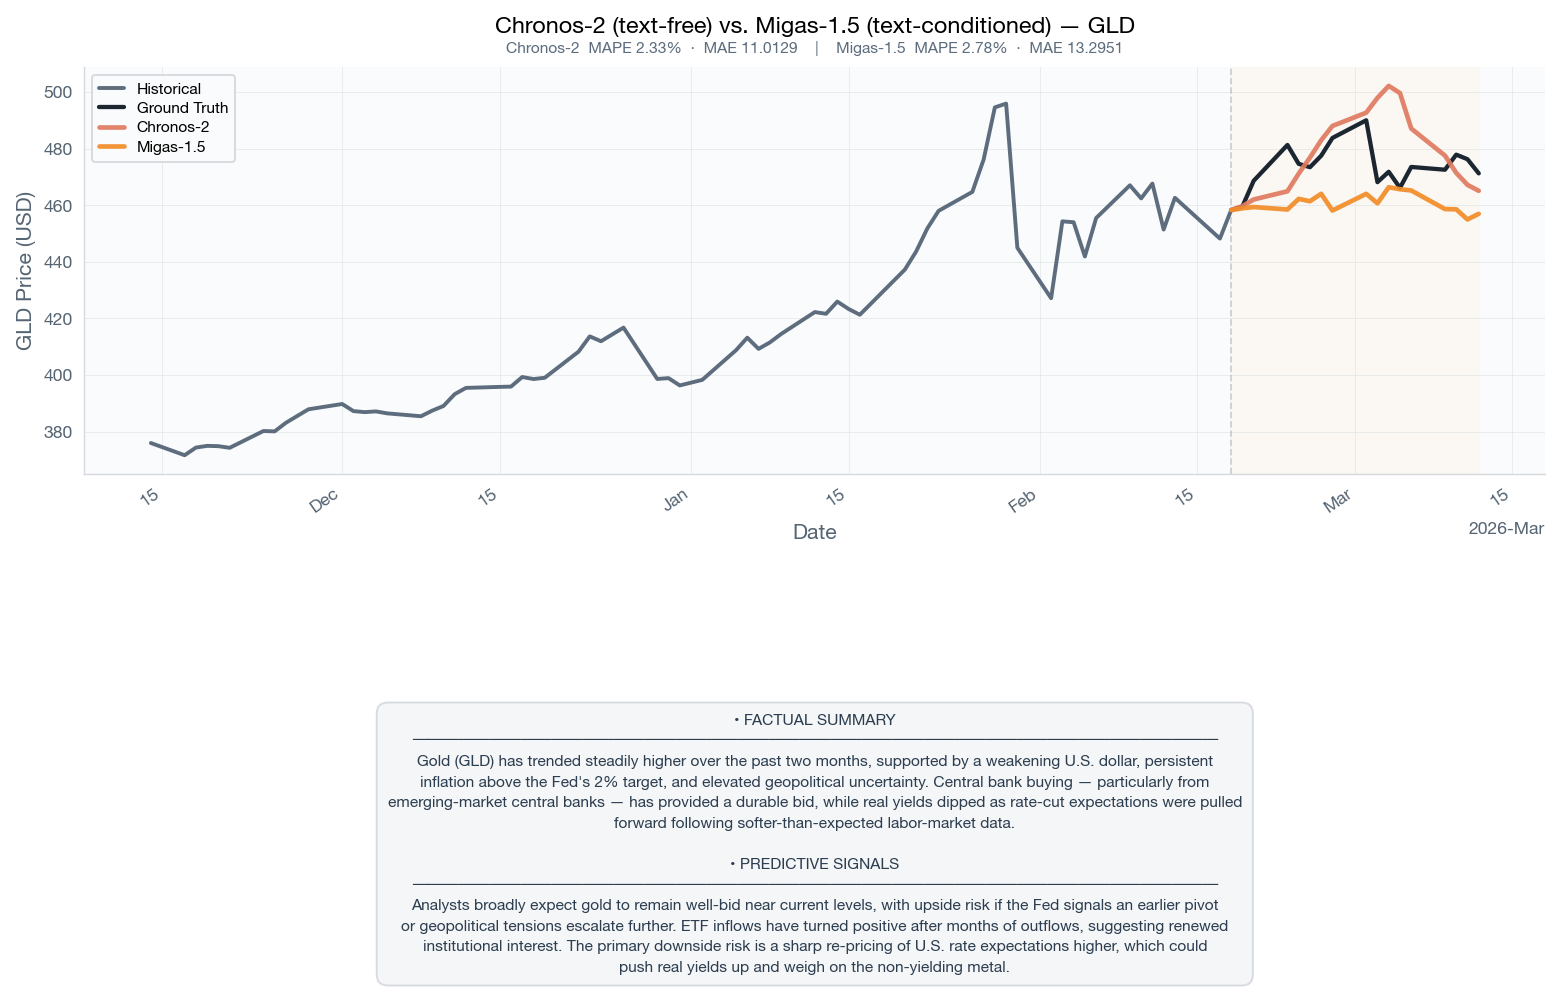

In [5]:
# Build timestamp sequence for the x-axis (context + forecast dates)
timestamps = list(full["t"].values)  # length SEQ_LEN + PRED_LEN

fig, ax = plot_forecast_single(
    context_vals,
    gt_vals,
    {"Chronos-2": chronos_fc, "Migas-1.5": migas_fc},
    SEQ_LEN,
    PRED_LEN,
    title=f"Chronos-2 (text-free) vs. Migas-1.5 (text-conditioned) — {TICKER}",
    figsize=(11, 4.2),
    show_metrics=True,
    timestamps=timestamps,
    text_summary=summary,
)
ax.set_ylabel(f"{TICKER} Price (USD)", color="#566573")
plt.show()

## What's next

- **Use your own data and summary** — see [Bring Your Own Data](migas-1.5-bring-your-own-data.ipynb), including an optional section that generates a window-aligned summary from real headlines via an LLM.
- **Counterfactual scenario analysis** — same numbers, different narrative → forecast shifts. See [Bring Your Own Data](migas-1.5-bring-your-own-data.ipynb) and [Counterfactual Scenarios](migas-1.5-counterfactual-scenarios.ipynb).
- **Rolling backtest with ground truth** — see [Backtest and Metrics](migas-1.5-backtest-and-metrics.ipynb).